In [1]:
# case study 3 start up profit prediction 

In [1]:
import pandas as pd 
import  numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df=pd.read_csv('50_Startups.csv')

In [3]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [4]:
df.shape

(50, 5)

In [5]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

In [8]:
df.T.duplicated().sum()

np.int64(0)

In [9]:
# step 3 EDA 

In [10]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [11]:
cm=df.corr(numeric_only=True)

In [12]:
cm

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


<Axes: >

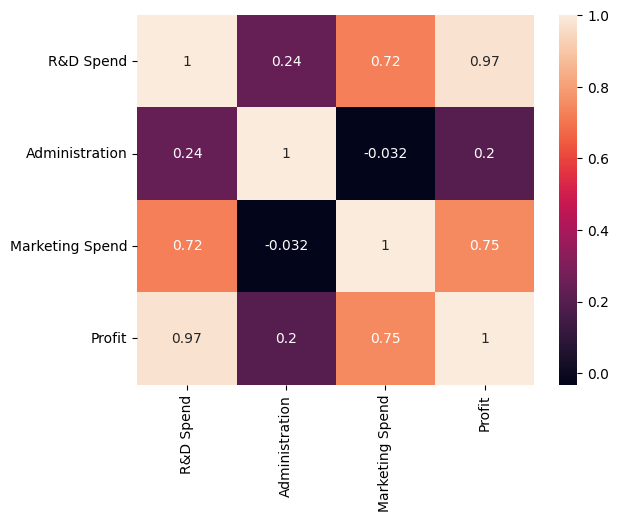

In [13]:
sns.heatmap(cm,annot=True)

In [14]:
# RD and profit has strong postive corr 

<Axes: xlabel='R&D Spend', ylabel='Profit'>

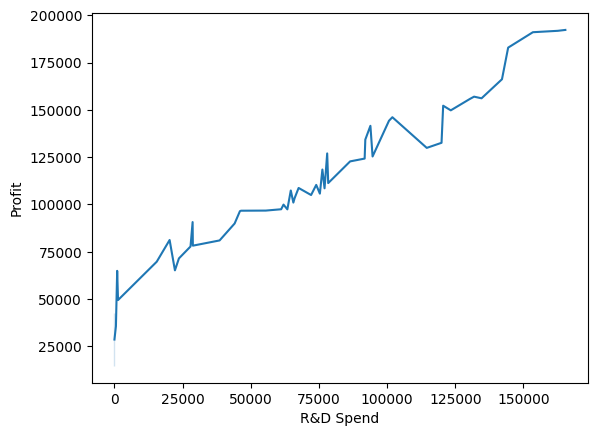

In [15]:
sns.lineplot(data=df,x='R&D Spend',y='Profit')

In [16]:
df.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

<Axes: xlabel='R&D Spend', ylabel='Profit'>

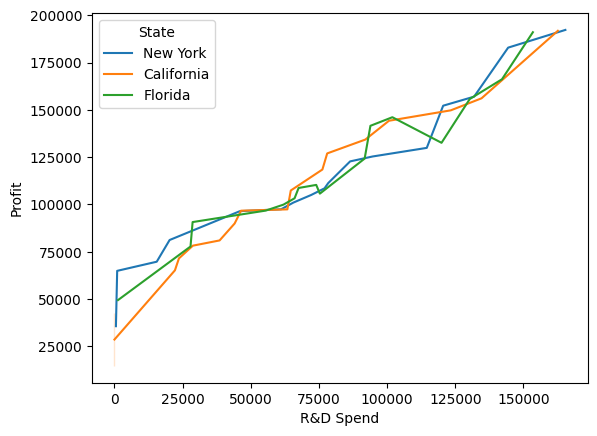

In [17]:
sns.lineplot(data=df,x='R&D Spend',y='Profit',hue='State')

<Axes: xlabel='State', ylabel='Profit'>

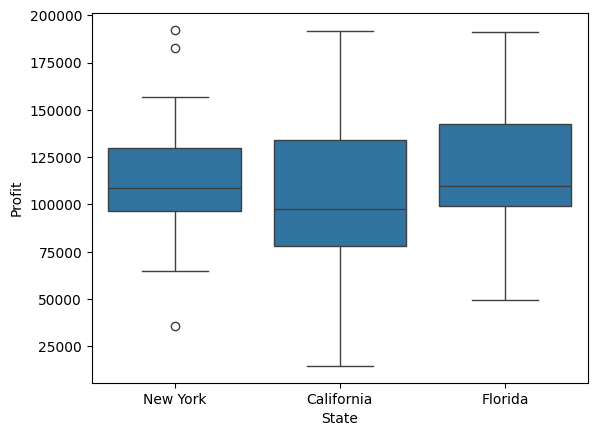

In [18]:
sns.boxplot(data=df,x='State',y='Profit')

<Axes: xlabel='Marketing Spend', ylabel='Profit'>

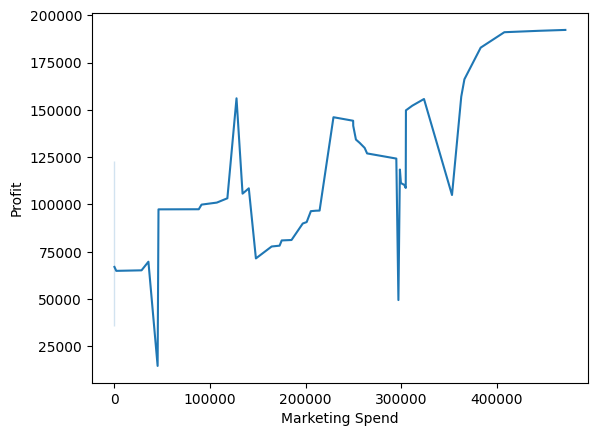

In [19]:
sns.lineplot(x='Marketing Spend',y='Profit',data=df)

In [20]:
# ML Preprocessing 

In [21]:
# seprate x and y

In [22]:
X=df.drop('Profit',axis=1) 
y=df['Profit']

In [23]:
X

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


In [24]:
y

0     192261.83
1     191792.06
2     191050.39
3     182901.99
4     166187.94
5     156991.12
6     156122.51
7     155752.60
8     152211.77
9     149759.96
10    146121.95
11    144259.40
12    141585.52
13    134307.35
14    132602.65
15    129917.04
16    126992.93
17    125370.37
18    124266.90
19    122776.86
20    118474.03
21    111313.02
22    110352.25
23    108733.99
24    108552.04
25    107404.34
26    105733.54
27    105008.31
28    103282.38
29    101004.64
30     99937.59
31     97483.56
32     97427.84
33     96778.92
34     96712.80
35     96479.51
36     90708.19
37     89949.14
38     81229.06
39     81005.76
40     78239.91
41     77798.83
42     71498.49
43     69758.98
44     65200.33
45     64926.08
46     49490.75
47     42559.73
48     35673.41
49     14681.40
Name: Profit, dtype: float64

In [23]:
# encoding 

In [25]:
from sklearn.preprocessing import OneHotEncoder 
oh=OneHotEncoder(sparse_output=False) 
X[oh.get_feature_names_out()]=oh.fit_transform(X[['State']])

In [26]:
X

,R&D Spend,Administration,Marketing Spend,State,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,New York,0.0,0.0,1.0
1,162597.70,151377.59,443898.53,California,1.0,0.0,0.0
2,153441.51,101145.55,407934.54,Florida,0.0,1.0,0.0
3,144372.41,118671.85,383199.62,New York,0.0,0.0,1.0
4,142107.34,91391.77,366168.42,Florida,0.0,1.0,0.0
5,131876.90,99814.71,362861.36,New York,0.0,0.0,1.0
6,134615.46,147198.87,127716.82,California,1.0,0.0,0.0
7,130298.13,145530.06,323876.68,Florida,0.0,1.0,0.0
8,120542.52,148718.95,311613.29,New York,0.0,0.0,1.0
9,123334.88,108679.17,304981.62,California,1.0,0.0,0.0


In [27]:
X.drop(columns=oh.feature_names_in_,inplace=True)

In [28]:
X

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0.0,0.0,1.0
1,162597.70,151377.59,443898.53,1.0,0.0,0.0
2,153441.51,101145.55,407934.54,0.0,1.0,0.0
3,144372.41,118671.85,383199.62,0.0,0.0,1.0
4,142107.34,91391.77,366168.42,0.0,1.0,0.0
5,131876.90,99814.71,362861.36,0.0,0.0,1.0
6,134615.46,147198.87,127716.82,1.0,0.0,0.0
7,130298.13,145530.06,323876.68,0.0,1.0,0.0
8,120542.52,148718.95,311613.29,0.0,0.0,1.0
9,123334.88,108679.17,304981.62,1.0,0.0,0.0


In [29]:
from sklearn.preprocessing import StandardScaler 
sc=StandardScaler() 
X[['R&D Spend','Administration','Marketing Spend']]=sc.fit_transform(X[['R&D Spend','Administration','Marketing Spend']])

In [30]:
X

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,2.016411,0.560753,2.153943,0.0,0.0,1.0
1,1.955860,1.082807,1.923600,1.0,0.0,0.0
2,1.754364,-0.728257,1.626528,0.0,1.0,0.0
3,1.554784,-0.096365,1.422210,0.0,0.0,1.0
4,1.504937,-1.079919,1.281528,0.0,1.0,0.0
5,1.279800,-0.776239,1.254210,0.0,0.0,1.0
6,1.340066,0.932147,-0.688150,1.0,0.0,0.0
7,1.245057,0.871980,0.932186,0.0,1.0,0.0
8,1.030369,0.986952,0.830887,0.0,0.0,1.0
9,1.091819,-0.456640,0.776107,1.0,0.0,0.0


In [37]:
# cross validation

In [31]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [32]:
X_train.shape

(40, 6)

In [33]:
X_test.shape

(10, 6)

In [34]:
y_train.shape

(40,)

In [35]:
y_test.shape

(10,)

In [43]:
# Model Training 

In [36]:
from sklearn.linear_model import LinearRegression 
reg=LinearRegression() 
reg.fit(X_train,y_train)

LinearRegression()

In [37]:
reg.coef_

array([36608.56770003, -1907.9151244 ,  3614.33667765,  -315.26025537,
         623.53275078,  -308.2724954 ])

In [38]:
reg.intercept_

np.float64(111688.85670089848)

In [48]:
#Model testing

In [39]:
reg.score(X_test,y_test)

0.8987266414319837

In [50]:
# 90 % score

In [41]:
y_pred=reg.predict(X_test)

In [42]:
y_pred

array([126362.87908252,  84608.45383643,  99677.49425155,  46357.46068582,
       128750.48288497,  50912.41741905, 109741.350327  , 100643.24281644,
        97599.275746  , 113097.42524437])

In [44]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score 

In [45]:
mean_absolute_error(y_test,y_pred)

6961.477813275562

In [46]:
root_mean_squared_error(y_test,y_pred)

9055.95732349781

In [47]:
r2_score(y_test,y_pred)

0.8987266414319837

In [57]:
# final model 

In [58]:
# Model deployment

In [48]:
import pickle

In [49]:
with open('model','wb') as f:
    pickle.dump(reg,f)

In [50]:
with open('encoder','wb') as f:
    pickle.dump(oh,f)

In [51]:
with open('scaler','wb') as f:
    pickle.dump(sc,f)

In [ ]:
'R&D Spend', 'Administration', 'Marketing Spend', 'State'

  75328.87         144135.98              134050.07      Florida

In [58]:
a={'R&D Spend':[75328.87 ],'Administration':[144135.98 ],'Marketing Spend':[134050.07 ],'State':['Florida']}

In [59]:
newdf=pd.DataFrame(a)

In [60]:
newdf

,R&D Spend,Administration,Marketing Spend,State
0,75328.87,144135.98,134050.07,Florida


In [61]:
newdf[oh.get_feature_names_out()]=oh.transform(newdf[['State']])

In [62]:
newdf.drop(columns=oh.feature_names_in_,inplace=True)

In [63]:
newdf

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,75328.87,144135.98,134050.07,0.0,1.0,0.0


In [64]:
newdf[['R&D Spend', 'Administration', 'Marketing Spend']]=sc.transform(newdf[['R&D Spend', 'Administration', 'Marketing Spend']])

In [65]:
newdf

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,0.03537,0.821718,-0.635835,0.0,1.0,0.0


In [66]:
reg.predict(newdf)

array([109741.350327])

In [67]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96
